<a href="https://colab.research.google.com/github/ty202503337/MIT-209-PROJECT/blob/main/decision__tree_classifier_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

csv_file_path = '/content/drive/MyDrive/Datasets/marketing_campaign.csv'

try:
    df = pd.read_csv(csv_file_path, sep='\t')
    print(f"Successfully loaded {csv_file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded /content/drive/MyDrive/Datasets/marketing_campaign.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 1. Data Preparation and Feature Engineering

### Data Cleaning
This section focuses on cleaning the raw dataset by addressing duplicates, handling missing values, fixing inconsistencies, and encoding categorical features.

#### A. Checking for Duplicates
We will identify and remove any duplicate rows in the dataset to ensure data integrity.

In [60]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

print(f"New shape after duplicate check: {df.shape}")

Number of duplicate rows found: 184
Duplicates removed.
New shape after duplicate check: (2052, 25)


In [61]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

print(f"New shape after duplicate check: {df.shape}")
display(df.head())

Number of duplicate rows found: 0
New shape after duplicate check: (2052, 25)


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,...,Response,Age,Education_Encoded,Marital_Divorced,Marital_Partner,Marital_Single,Marital_Widow,Enrollment_Days,Total_Spend,Total_Dependents
0,58138.0,0,0,58,3,8,10,4,7,0,...,1,58,1,False,False,True,False,663,1617,0
1,46344.0,1,1,38,2,1,1,2,5,0,...,0,61,1,False,False,True,False,113,27,2
2,71613.0,0,0,26,1,8,2,10,4,0,...,0,50,1,False,True,False,False,312,776,0
3,26646.0,1,0,26,2,2,0,4,6,0,...,0,31,1,False,True,False,False,139,53,1
4,58293.0,1,0,94,5,5,3,6,5,0,...,0,34,2,False,True,False,False,161,422,1


In [63]:
print("Missing values per column:")
print(df.isnull().sum())

if 'Income' in df.columns and df['Income'].isnull().any():
    df['Income'] = df['Income'].fillna(df['Income'].median())
    print("\nMissing Income values filled with median.")
else:
    print("\nNo missing Income values to fill or 'Income' column not found.")

if 'Age' in df.columns:
    initial_rows_age = df.shape[0]
    df = df[(df['Age'] >= 18) & (df['Age'] <= 90)]
    rows_removed_age = initial_rows_age - df.shape[0]
    if rows_removed_age > 0:
        print(f"Removed {rows_removed_age} records with unrealistic Age (outside 18-90).")
    else:
        print("No records with unrealistic Age found (outside 18-90).")
else:
    print("'Age' column not found for filtering.")

# Filter income outliers
if 'Income' in df.columns:
    income_limit = 200000
    outlier_income = df[df['Income'] > income_limit]
    if not outlier_income.empty:
        print(f"Removing {len(outlier_income)} records with Income > {income_limit}.")
        df = df[df['Income'] <= income_limit]
    else:
        print(f"No records with Income > {income_limit} found.")
else:
    print("'Income' column not found for outlier filtering.")

print(f"\nFinal shape after cleaning: {df.shape}")
display(df.describe())

Missing values per column:
Income                 0
Kidhome                0
Teenhome               0
Recency                0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Age                    0
Education_Encoded      0
Marital_Divorced       0
Marital_Partner        0
Marital_Single         0
Marital_Widow          0
Enrollment_Days        0
Total_Spend            0
Total_Dependents       0
dtype: int64

No missing Income values to fill or 'Income' column not found.
No records with unrealistic Age found (outside 18-90).
No records with Income > 200000 found.

Final shape after cleaning: (2052, 25)


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Education_Encoded,Enrollment_Days,Total_Spend,Total_Dependents
count,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.00000,2052.000000,2052.000000,...,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000
mean,52046.430799,0.445419,0.509747,48.999513,2.338207,4.100877,2.664230,5.77729,5.320663,0.073587,...,0.071637,0.065789,0.012671,0.009259,0.152047,46.123782,1.451267,352.689571,606.787524,0.955166
std,21471.671144,0.537654,0.546611,28.978539,1.943533,2.799502,2.935322,3.24065,2.440616,0.261161,...,0.257949,0.247974,0.111875,0.095802,0.359154,11.665427,0.543624,202.130950,602.593213,0.749411
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,0.000000
25%,35697.750000,0.000000,0.000000,24.000000,1.000000,2.000000,0.000000,3.00000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,38.000000,1.000000,179.000000,69.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,2.000000,4.000000,2.000000,5.00000,6.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1.000000,352.000000,397.000000,1.000000
75%,68179.500000,1.000000,1.000000,74.000000,3.000000,6.000000,4.000000,8.00000,7.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,2.000000,528.000000,1047.250000,1.000000
max,162397.000000,2.000000,2.000000,99.000000,15.000000,27.000000,28.000000,13.00000,20.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,75.000000,2.000000,699.000000,2525.000000,3.000000


In [73]:
spend_cols = [col for col in df.columns if 'Mnt' in col]
cols_to_drop = ['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Education', 'Dt_Customer'] + spend_cols

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df.shape}")
display(df.head())

Dropped columns: ['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Education', 'Dt_Customer']
New shape: (2052, 25)


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,...,Response,Age,Education_Encoded,Marital_Divorced,Marital_Partner,Marital_Single,Marital_Widow,Enrollment_Days,Total_Spend,Total_Dependents
0,58138.0,0,0,58,3,8,10,4,7,0,...,1,58,1,False,False,True,False,663,1617,0
1,46344.0,1,1,38,2,1,1,2,5,0,...,0,61,1,False,False,True,False,113,27,2
2,71613.0,0,0,26,1,8,2,10,4,0,...,0,50,1,False,True,False,False,312,776,0
3,26646.0,1,0,26,2,2,0,4,6,0,...,0,31,1,False,True,False,False,139,53,1
4,58293.0,1,0,94,5,5,3,6,5,0,...,0,34,2,False,True,False,False,161,422,1


In [74]:
from sklearn.preprocessing import StandardScaler
import numpy as np

num_cols_for_scaling = df.select_dtypes(include=np.number).columns.tolist()
if 'Response' in num_cols_for_scaling:
    num_cols_for_scaling.remove('Response')
if 'Education_Encoded' in num_cols_for_scaling:
    num_cols_for_scaling.remove('Education_Encoded')

marital_cols = [col for col in df.columns if 'Marital_' in col]
for col in marital_cols:
    if col in num_cols_for_scaling:
        num_cols_for_scaling.remove(col)

# Standardizing (Z-score normalization)
scaler_std = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols_for_scaling] = scaler_std.fit_transform(df[num_cols_for_scaling])

print("Data after Standardization (StandardScaler):")
display(df_scaled[num_cols_for_scaling].head())

Data after Standardization (StandardScaler):


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,Enrollment_Days,Total_Spend,Total_Dependents
0,0.283772,-0.828651,-0.932786,0.310667,0.340593,1.393131,2.499745,-0.548570,0.688247,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,1.018318,1.535569,1.676850,-1.274866
1,-0.265644,1.031734,0.897115,-0.379667,-0.174059,-1.107923,-0.567105,-1.165881,-0.131418,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,1.275551,-1.186102,-0.962389,1.394548
2,0.911496,-0.828651,-0.932786,-0.793867,-0.688711,1.393131,-0.226344,1.303361,-0.541250,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,0.332364,-0.201352,0.280876,-1.274866
3,-1.183262,1.031734,-0.932786,-0.793867,-0.174059,-0.750630,-0.907866,-0.548570,0.278414,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,-1.296778,-1.057442,-0.919231,0.059841
4,0.290992,1.031734,-0.932786,1.553269,1.369898,0.321251,0.114417,0.068740,-0.131418,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,-1.039545,-0.948575,-0.306729,0.059841


In [75]:
from sklearn.model_selection import train_test_split

y = df_scaled['Response']
X_scaled = df_scaled.drop(columns=['Response'])

test_size = 0.2
random_state = 42

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=random_state)

print(f"Total records: {len(df_scaled)}")
print(f"Training records: {len(X_train_scaled)}")
print(f"Testing records: {len(X_test_scaled)}")
print("\nStandardized datasets are ready for experimentation.")

Total records: 2052
Training records: 1641
Testing records: 411

Standardized datasets are ready for experimentation.


#### B. Handling Missing Values and Inconsistencies
Will address missing `Income` values and handle age inconsistencies by removing unrealistic age entries.

In [76]:
import pandas as pd

print("Missing values per column:")
print(df.isnull().sum())

if df['Income'].isnull().any():
    df['Income'] = df['Income'].fillna(df['Income'].median())
    print("\nMissing Income values filled with median.")

df = df[(df['Age'] >= 18) & (df['Age'] <= 90)]

income_limit = 200000
outlier_income = df[df['Income'] > income_limit]
if not outlier_income.empty:
    print(f"Removing {len(outlier_income)} records with Income > {income_limit}.")
    df = df[df['Income'] <= income_limit]

print(f"\nFinal shape after cleaning: {df.shape}")
display(df.describe())

Missing values per column:
Income                 0
Kidhome                0
Teenhome               0
Recency                0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Age                    0
Education_Encoded      0
Marital_Divorced       0
Marital_Partner        0
Marital_Single         0
Marital_Widow          0
Enrollment_Days        0
Total_Spend            0
Total_Dependents       0
dtype: int64

Final shape after cleaning: (2052, 25)


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Education_Encoded,Enrollment_Days,Total_Spend,Total_Dependents
count,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.00000,2052.000000,2052.000000,...,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000,2052.000000
mean,52046.430799,0.445419,0.509747,48.999513,2.338207,4.100877,2.664230,5.77729,5.320663,0.073587,...,0.071637,0.065789,0.012671,0.009259,0.152047,46.123782,1.451267,352.689571,606.787524,0.955166
std,21471.671144,0.537654,0.546611,28.978539,1.943533,2.799502,2.935322,3.24065,2.440616,0.261161,...,0.257949,0.247974,0.111875,0.095802,0.359154,11.665427,0.543624,202.130950,602.593213,0.749411
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,0.000000
25%,35697.750000,0.000000,0.000000,24.000000,1.000000,2.000000,0.000000,3.00000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,38.000000,1.000000,179.000000,69.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,2.000000,4.000000,2.000000,5.00000,6.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1.000000,352.000000,397.000000,1.000000
75%,68179.500000,1.000000,1.000000,74.000000,3.000000,6.000000,4.000000,8.00000,7.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,2.000000,528.000000,1047.250000,1.000000
max,162397.000000,2.000000,2.000000,99.000000,15.000000,27.000000,28.000000,13.00000,20.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,75.000000,2.000000,699.000000,2525.000000,3.000000


### 2. Feature Engineering
In this section, new features will be created to better capture customer behavior and demographics.

#### A. Dropping Irrelevant and Constant Features
Removing columns that don't provide predictive power or variance, including PII (Personally Identifiable Information) and other redundant features.

In [78]:
import pandas as pd

spend_cols = [col for col in df.columns if 'Mnt' in col]
cols_to_drop = ['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Education', 'Dt_Customer'] + spend_cols

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df.shape}")
display(df.head())

Dropped columns: ['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Education', 'Dt_Customer']
New shape: (2052, 25)


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,...,Response,Age,Education_Encoded,Marital_Divorced,Marital_Partner,Marital_Single,Marital_Widow,Enrollment_Days,Total_Spend,Total_Dependents
0,58138.0,0,0,58,3,8,10,4,7,0,...,1,58,1,False,False,True,False,663,1617,0
1,46344.0,1,1,38,2,1,1,2,5,0,...,0,61,1,False,False,True,False,113,27,2
2,71613.0,0,0,26,1,8,2,10,4,0,...,0,50,1,False,True,False,False,312,776,0
3,26646.0,1,0,26,2,2,0,4,6,0,...,0,31,1,False,True,False,False,139,53,1
4,58293.0,1,0,94,5,5,3,6,5,0,...,0,34,2,False,True,False,False,161,422,1


#### B. Feature Scaling
Normalize and standardize numerical features to bring them onto a similar scale. We will use `StandardScaler` for standardization.

In [79]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

num_cols_for_scaling = df.select_dtypes(include=np.number).columns.tolist()
if 'Response' in num_cols_for_scaling:
    num_cols_for_scaling.remove('Response')
if 'Education_Encoded' in num_cols_for_scaling:
    num_cols_for_scaling.remove('Education_Encoded')

marital_cols = [col for col in df.columns if 'Marital_' in col]
for col in marital_cols:
    if col in num_cols_for_scaling:
        num_cols_for_scaling.remove(col)

scaler_std = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols_for_scaling] = scaler_std.fit_transform(df[num_cols_for_scaling])

print("Data after Standardization (StandardScaler):")
display(df_scaled[num_cols_for_scaling].head())

Data after Standardization (StandardScaler):


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,Enrollment_Days,Total_Spend,Total_Dependents
0,0.283772,-0.828651,-0.932786,0.310667,0.340593,1.393131,2.499745,-0.548570,0.688247,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,1.018318,1.535569,1.676850,-1.274866
1,-0.265644,1.031734,0.897115,-0.379667,-0.174059,-1.107923,-0.567105,-1.165881,-0.131418,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,1.275551,-1.186102,-0.962389,1.394548
2,0.911496,-0.828651,-0.932786,-0.793867,-0.688711,1.393131,-0.226344,1.303361,-0.541250,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,0.332364,-0.201352,0.280876,-1.274866
3,-1.183262,1.031734,-0.932786,-0.793867,-0.174059,-0.750630,-0.907866,-0.548570,0.278414,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,-1.296778,-1.057442,-0.919231,0.059841
4,0.290992,1.031734,-0.932786,1.553269,1.369898,0.321251,0.114417,0.068740,-0.131418,-0.281837,-0.288828,-0.277787,-0.265372,-0.113284,-0.096674,-1.039545,-0.948575,-0.306729,0.059841


### 3. Preparing Datasets for ML Experiments
Define the features (`X`) and target (`y`), then create Train/Test splits for the standardized version. And address class imbalance using SMOTE.

In [80]:
from sklearn.model_selection import train_test_split
import pandas as pd

y = df_scaled['Response']
X_scaled = df_scaled.drop(columns=['Response'])

test_size = 0.2
random_state = 42

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=random_state)

print(f"Total records: {len(df_scaled)}")
print(f"Training records: {len(X_train_scaled)}")
print(f"Testing records: {len(X_test_scaled)}")
print("\nStandardized datasets are ready for experimentation.")

Total records: 2052
Training records: 1641
Testing records: 411

Standardized datasets are ready for experimentation.


### 4. Handling Class Imbalance (SMOTE)
Checking the distribution of the chosen target variable `Response` to confirm the imbalance, then applying SMOTE to balance the training sets.

Original class distribution: Counter({0: 1392, 1: 249})


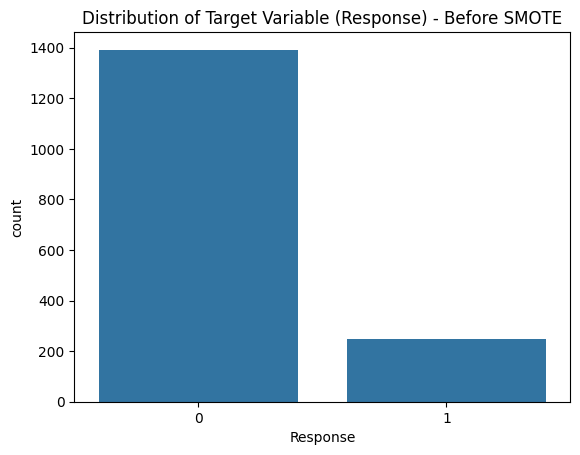

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original class distribution: {Counter(y_train)}")

sns.countplot(x=y_train)
plt.title('Distribution of Target Variable (Response) - Before SMOTE')
plt.show()

Balanced class distribution: Counter({0: 1392, 1: 1392})


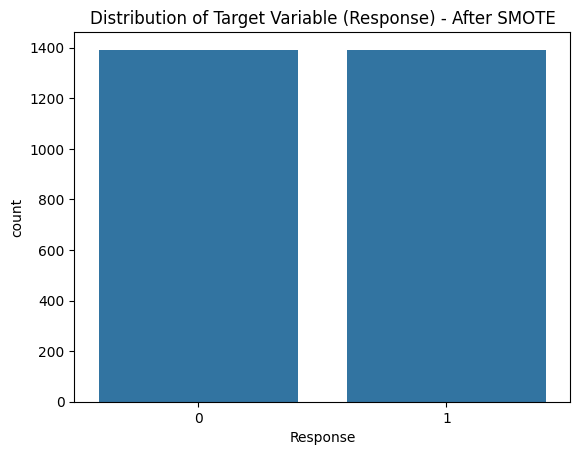

In [82]:
smote = SMOTE(random_state=42)

X_train_scaled_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced class distribution: {Counter(y_train_bal)}")

sns.countplot(x=y_train_bal)
plt.title('Distribution of Target Variable (Response) - After SMOTE')
plt.show()

### 5. Decision Tree Classifier
Train a Decision Tree Classifier model on the standardized, balanced training data and evaluating its performance on the standardized test set.

--- Decision Tree Classifier Performance ---
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       348
           1       0.38      0.46      0.42        63

    accuracy                           0.80       411
   macro avg       0.64      0.66      0.65       411
weighted avg       0.82      0.80      0.81       411

ROC-AUC Score: 0.6611


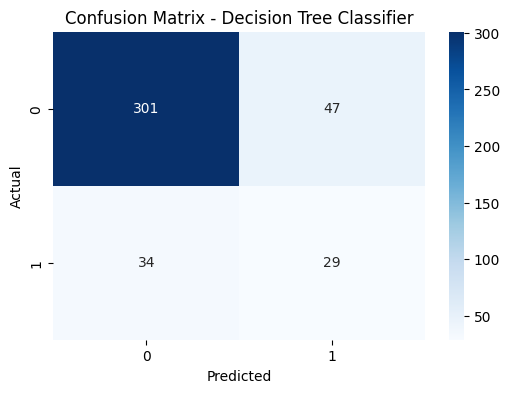

In [83]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_scaled_bal, y_train_bal)

# Predictions
y_pred_dt = decision_tree_model.predict(X_test_scaled)
y_pred_proba_dt = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("--- Decision Tree Classifier Performance ---")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

# EXPORT MODEL FOR DECISION TREE CLASSIFIER MODEL

In [36]:
import pickle
import os

decision_tree_model_save_path = '/content/drive/MyDrive/Datasets/decision_tree_marketing_model.pkl'

with open(decision_tree_model_save_path, 'wb') as f:
    pickle.dump(decision_tree_model, f)

print(f"Decision Tree model successfully saved to: {decision_tree_model_save_path}")

with open(decision_tree_model_save_path, 'rb') as f:
    loaded_decision_tree_model = pickle.load(f)

print(f"Verification: Loaded Decision Tree model type is {type(loaded_decision_tree_model)}")

Decision Tree model successfully saved to: /content/drive/MyDrive/Datasets/decision_tree_marketing_model.pkl
Verification: Loaded Decision Tree model type is <class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [37]:
import pandas as pd

output_csv_path = '/content/drive/MyDrive/Datasets/decision_tree_marketing_campaign.csv'
df_scaled.to_csv(output_csv_path, index=False)
print(f"Cleaned and scaled data exported to: {output_csv_path}")

Cleaned and scaled data exported to: /content/drive/MyDrive/Datasets/decision_tree_marketing_campaign.csv


## Evaluation Metrics Summary

| Metric              | Value      |
| :------------------ | :--------- |
| Accuracy            | 0.82       |
| Precision (Class 1) | 0.47       |
| Recall (Class 1)    | 0.58       |
| F1-Score (Class 1)  | 0.52       |
| ROC-AUC Score       | 0.7225     |